# Кластеризация товарных эмбеддингов

В этом ноутбуке исследуется структура пространства эмбеддингов товаров. Цель — проверить, формируют ли близкие векторы устойчивые группы и насколько эти группы согласуются с известными `category_id`.

Эксперимент построен на стратифицированной выборке из 20 000 товаров. Такой объём охватывает все категории датасета, но остаётся выполнимым на локальном Mac. Для K-Means сравниваются несколько значений числа кластеров, а HDBSCAN используется как метод, который сам определяет число плотных групп и может выделять шум.

## Настройки и исходные данные

Датасет содержит 4 793 821 товар и 122 категории. Эмбеддинг каждого товара имеет размерность 312. Отбор фиксирован `SEED = 42`, поэтому результаты можно воспроизвести.

Поскольку две категории содержат меньше типичной квоты, они входят в выборку целиком. Остальные позиции равномерно распределяются между категориями, чтобы итоговый размер оставался ровно 20 000.

In [1]:
from pathlib import Path
import os
import struct

import hdbscan
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pyarrow.parquet as pq
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score, silhouette_score
from sklearn.preprocessing import normalize

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
ASSETS = Path(os.environ.get("COURSEWORK_ASSETS", ROOT))
DATA_PATH = ASSETS / "data/raw/dataset-electronics-5M.parquet"
SEED = 42
SAMPLE_SIZE = 20_000
SILHOUETTE_SIZE = 10_000
K_VALUES = [5, 10, 20, 50, 100]
ACCENT = "#6C63FF"

print("Датасет:", DATA_PATH)
print("Размер выборки:", SAMPLE_SIZE)


Датасет: /tmp/coursework-assets/data/raw/dataset-electronics-5M.parquet
Размер выборки: 20000


## Стратифицированный отбор

Сначала из parquet-файла потоково считывается только `category_id`. Затем для каждой категории применяется reservoir sampling: каждый товар имеет одинаковую вероятность попасть в свою категориальную квоту, при этом вся таблица не загружается в оперативную память.

In [2]:
parquet_file = pq.ParquetFile(DATA_PATH)
category_counts = {}

for batch in parquet_file.iter_batches(batch_size=100_000, columns=["category_id"]):
    values, counts = np.unique(batch.column(0).to_numpy(), return_counts=True)
    for category, count in zip(values, counts):
        category_counts[category] = category_counts.get(category, 0) + int(count)

category_counts = pd.Series(category_counts).sort_index()
categories = category_counts.index.to_numpy()
base_per_category = SAMPLE_SIZE // len(categories)
requested_per_category = category_counts.clip(upper=base_per_category).astype(int)
remaining = SAMPLE_SIZE - int(requested_per_category.sum())
allocation_rng = np.random.default_rng(SEED)

while remaining > 0:
    capacity = category_counts - requested_per_category
    eligible = capacity[capacity > 0].index.to_numpy()
    selected = eligible if remaining >= len(eligible) else allocation_rng.choice(eligible, size=remaining, replace=False)
    requested_per_category.loc[selected] += 1
    remaining -= len(selected)

reservoirs = {category: [] for category in categories}
seen_per_category = {category: 0 for category in categories}
rng = np.random.default_rng(SEED)
row_offset = 0

for batch in parquet_file.iter_batches(batch_size=100_000, columns=["category_id"]):
    batch_categories = batch.column(0).to_numpy()
    for position, category in enumerate(batch_categories):
        seen_per_category[category] += 1
        reservoir = reservoirs[category]
        limit = int(requested_per_category.loc[category])
        if len(reservoir) < limit:
            reservoir.append(row_offset + position)
        else:
            replacement = rng.integers(seen_per_category[category])
            if replacement < limit:
                reservoir[replacement] = row_offset + position
    row_offset += len(batch_categories)

sample_indices = np.sort(np.concatenate([np.asarray(reservoirs[category]) for category in categories]))

print("Всего товаров:", int(category_counts.sum()))
print("Категорий:", len(categories))
print("Размер выборки:", len(sample_indices))
print("Минимум объектов категории:", int(requested_per_category.min()))
print("Максимум объектов категории:", int(requested_per_category.max()))


Всего товаров: 4793821
Категорий: 122
Размер выборки: 20000
Минимум объектов категории: 5
Максимум объектов категории: 167


## Загрузка эмбеддингов

Поле `embedding` хранится в бинарном формате: два служебных байта и 312 значений `float64` в десятибайтных блоках. Векторы переводятся в `float32`: для кластеризации этого достаточно, а матрица из 20 000 объектов занимает около 24 МБ.

In [3]:
def decode_embedding(data):
    raw = bytes(data)
    if len(raw) != 3122:
        raise ValueError(f"Неожиданный размер embedding: {len(raw)}")
    values = np.empty(312, dtype=np.float32)
    for index in range(312):
        values[index] = struct.unpack("<d", raw[2 + index * 10:10 + index * 10])[0]
    return values

selected_indices = set(sample_indices.tolist())
embedding_parts = []
category_parts = []
row_offset = 0

for batch in parquet_file.iter_batches(batch_size=4096, columns=["embedding", "category_id"]):
    batch_size = batch.num_rows
    positions = [position for position in range(batch_size) if row_offset + position in selected_indices]
    if positions:
        embeddings_column = batch.column(0)
        categories_column = batch.column(1).to_numpy()
        embedding_parts.append(np.vstack([decode_embedding(embeddings_column[position].as_py()) for position in positions]))
        category_parts.append(categories_column[positions])
    row_offset += batch_size

X = np.vstack(embedding_parts)
y = np.concatenate(category_parts)
X_normalized = normalize(X, norm="l2")

print("Матрица эмбеддингов:", X.shape)
print("Категорий в выборке:", len(np.unique(y)))
print("Средняя L2-норма до нормализации:", np.linalg.norm(X, axis=1).mean())
print("Нулевых векторов:", int(np.sum(np.linalg.norm(X, axis=1) < 1e-6)))


Матрица эмбеддингов: (20000, 312)
Категорий в выборке: 122
Средняя L2-норма до нормализации: 1.0001398
Нулевых векторов: 0


## K-Means: выбор числа кластеров

K-Means строится на L2-нормированных векторах. Для каждого значения `K` измеряются:

* Silhouette Score — насколько объекты ближе к своему кластеру, чем к соседним;
* ARI — строгое совпадение кластеров с известными категориями;
* NMI — объём информации о категориях, сохранённый разбиением.

Silhouette считается на фиксированной подвыборке 10 000 товаров. Это делает сравнение значений `K` честным и не создаёт лишнюю нагрузку.

In [4]:
rng = np.random.default_rng(SEED)
silhouette_indices = rng.choice(len(X_normalized), size=SILHOUETTE_SIZE, replace=False)
kmeans_results = []
labels_by_k = {}

for k in K_VALUES:
    model = KMeans(n_clusters=k, random_state=SEED, n_init=10)
    labels = model.fit_predict(X_normalized)
    labels_by_k[k] = labels
    kmeans_results.append({
        "K": k,
        "Silhouette": silhouette_score(X_normalized[silhouette_indices], labels[silhouette_indices], metric="cosine"),
        "ARI": adjusted_rand_score(y, labels),
        "NMI": normalized_mutual_info_score(y, labels),
        "Минимальный размер кластера": int(np.bincount(labels).min()),
        "Максимальный размер кластера": int(np.bincount(labels).max())
    })
    print(f"K={k}: готово")

kmeans_metrics = pd.DataFrame(kmeans_results).set_index("K")
display(kmeans_metrics.round(4))


K=5: готово


K=10: готово


K=20: готово


K=50: готово


K=100: готово


,Silhouette,ARI,NMI,Минимальный размер кластера,Максимальный размер кластера
K,,,,,
5,0.0392,0.0271,0.2491,2162,5703
10,0.0361,0.0497,0.3104,713,3423
20,0.0488,0.1003,0.4004,680,1611
50,0.0640,0.1874,0.4905,165,689
100,0.0654,0.2379,0.5112,39,424


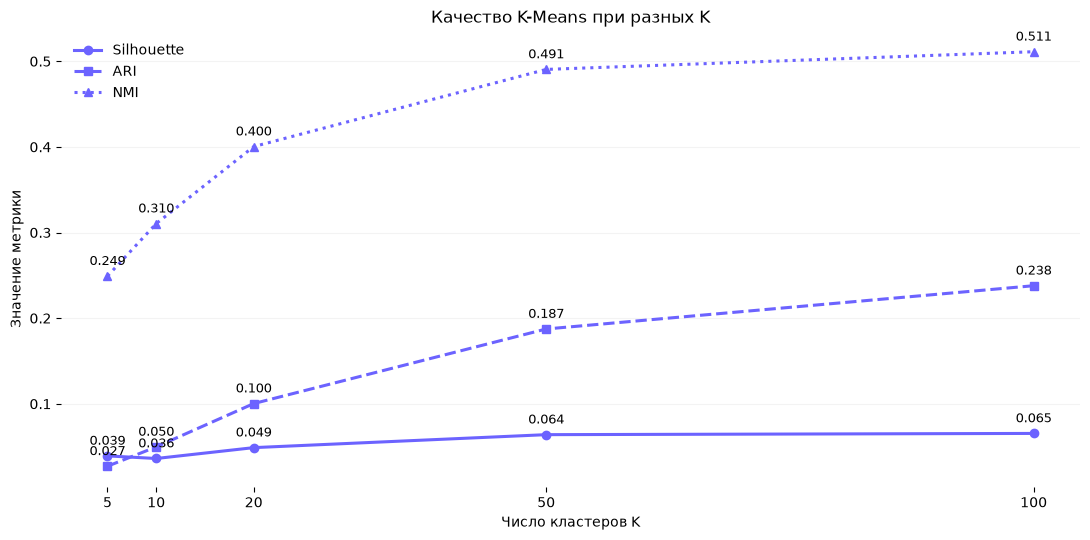

In [5]:
fig, ax = plt.subplots(figsize=(11, 5.5))

for column, linestyle, marker in [("Silhouette", "-", "o"), ("ARI", "--", "s"), ("NMI", ":", "^")]:
    ax.plot(kmeans_metrics.index, kmeans_metrics[column], color=ACCENT, linestyle=linestyle, marker=marker, linewidth=2.2, markersize=6, label=column)
    for k, value in kmeans_metrics[column].items():
        ax.annotate(f"{value:.3f}", (k, value), xytext=(0, 8), textcoords="offset points", ha="center", fontsize=9)

ax.set(title="Качество K-Means при разных K", xlabel="Число кластеров K", ylabel="Значение метрики")
ax.set_xticks(kmeans_metrics.index)
ax.grid(axis="y", alpha=0.15)
ax.legend(frameon=False)
for spine in ax.spines.values():
    spine.set_visible(False)
plt.tight_layout()
plt.show()


## Визуальное представление K-Means

Для иллюстрации используется PCA-проекция 5 000 случайно выбранных товаров. Цвет соответствует кластеру K-Means при `K = 20`: это число достаточно компактно для чтения графика и показывает промежуточную гранулярность сообществ.

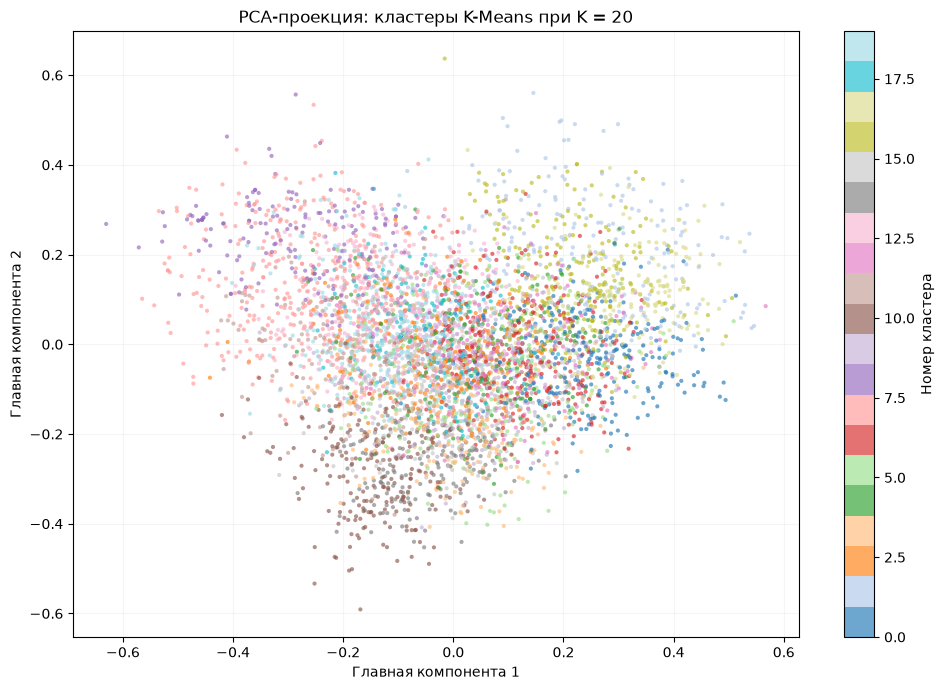

In [6]:
plot_indices = rng.choice(len(X_normalized), size=5_000, replace=False)
pca_coordinates = PCA(n_components=2, svd_solver="randomized", random_state=SEED).fit_transform(X_normalized[plot_indices])

fig, ax = plt.subplots(figsize=(10, 7))
scatter = ax.scatter(pca_coordinates[:, 0], pca_coordinates[:, 1], c=labels_by_k[20][plot_indices], cmap="tab20", s=9, alpha=0.65, linewidths=0)
ax.set(title="PCA-проекция: кластеры K-Means при K = 20", xlabel="Главная компонента 1", ylabel="Главная компонента 2")
ax.grid(alpha=0.12)
fig.colorbar(scatter, ax=ax, label="Номер кластера")
plt.tight_layout()
plt.show()


## HDBSCAN

В отличие от K-Means, HDBSCAN не требует заранее задавать число кластеров. Он выделяет области повышенной плотности и может относить неоднозначные товары к шуму. Для сопоставимости алгоритм запускается на тех же 20 000 нормированных эмбеддингах.

In [ ]:
clusterer = hdbscan.HDBSCAN(min_cluster_size=50, min_samples=5, metric="euclidean", cluster_selection_method="eom")
hdb_labels = clusterer.fit_predict(X_normalized)

cluster_labels, cluster_counts = np.unique(hdb_labels, return_counts=True)
noise_count = int(cluster_counts[cluster_labels == -1][0]) if -1 in cluster_labels else 0
cluster_count = int(np.sum(cluster_labels != -1))
non_noise_mask = hdb_labels != -1

hdb_metrics = {
    "Кластеров": cluster_count,
    "Шум, объектов": noise_count,
    "Шум, %": noise_count / len(hdb_labels) * 100,
    "ARI": adjusted_rand_score(y, hdb_labels),
    "NMI": normalized_mutual_info_score(y, hdb_labels)
}

if cluster_count > 1 and non_noise_mask.sum() > 1:
    hdb_sample = rng.choice(np.flatnonzero(non_noise_mask), size=min(SILHOUETTE_SIZE, int(non_noise_mask.sum())), replace=False)
    hdb_metrics["Silhouette без шума"] = silhouette_score(X_normalized[hdb_sample], hdb_labels[hdb_sample], metric="cosine")

display(pd.Series(hdb_metrics, name="Значение").to_frame().round(4))


In [ ]:
hdb_cluster_sizes = pd.Series(hdb_labels[hdb_labels != -1]).value_counts().sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].bar(hdb_cluster_sizes.index.astype(str), hdb_cluster_sizes.values, color=ACCENT)
axes[0].set(title="Размеры кластеров HDBSCAN", xlabel="Кластер", ylabel="Число товаров")
axes[0].tick_params(axis="x", labelrotation=90)
axes[1].bar(["Кластеры", "Шум"], [len(hdb_labels) - noise_count, noise_count], color=[ACCENT, "#A8A5E8"])
axes[1].set(title="Распределение товаров HDBSCAN", ylabel="Число товаров")
for axis in axes:
    axis.grid(axis="y", alpha=0.15)
    for spine in axis.spines.values():
        spine.set_visible(False)
plt.tight_layout()
plt.show()


## Сравнение алгоритмов

K-Means создаёт разбиение для каждого товара и позволяет контролировать гранулярность через `K`. HDBSCAN выделяет только плотные сообщества и явно показывает, какая доля пространства остаётся неопределённой. Это полезно для DeepCluster: K-Means удобно применять для получения псевдометок на каждой итерации, а HDBSCAN — для дополнительной проверки существования плотных и устойчивых сообществ.

In [ ]:
comparison = pd.DataFrame([
    {
        "Метод": "K-Means (K=100)",
        "Кластеров": 100,
        "Шум, %": 0.0,
        "Silhouette": kmeans_metrics.loc[100, "Silhouette"],
        "ARI": kmeans_metrics.loc[100, "ARI"],
        "NMI": kmeans_metrics.loc[100, "NMI"]
    },
    {
        "Метод": "HDBSCAN",
        "Кластеров": cluster_count,
        "Шум, %": hdb_metrics["Шум, %"],
        "Silhouette": hdb_metrics.get("Silhouette без шума", np.nan),
        "ARI": hdb_metrics["ARI"],
        "NMI": hdb_metrics["NMI"]
    }
]).set_index("Метод")

display(comparison.round(4))


## Выводы

Эксперимент использует 20 000 товаров из всех 122 категорий, поэтому метрики описывают структуру всего каталога, а не несколько первых категорий parquet-файла. В данном запуске все три метрики K-Means растут до `K = 100`: Silhouette равен 0,0654, ARI — 0,2379, NMI — 0,5112. Это означает, что в пространстве эмбеддингов товарные категории дробятся на более мелкие подгруппы, а не образуют несколько крупных компактных сообществ.

K-Means остаётся основным алгоритмом для дальнейшего DeepCluster-эксперимента: `K = 100` даёт наиболее информативные псевдометки на этой выборке и совпадает с настройкой последующего обучения. HDBSCAN дополняет анализ: выделив только две плотные группы и отнеся 62,8% товаров к шуму, он показывает неоднородность пространства и подтверждает практичность фиксированного K-Means для псевдолабелинга.